In [1]:
from importlib import reload
import core

import networkx as nx

from core.PlotGraph import plotGraph
import pandas as pd

from core.solver.IngredientSolver import IngredientSolver

pd.set_option('display.max_rows', 30)

from core.GraphCreator import GraphCreator
from core.PropagationAlgorithm import Propagation

%load_ext autoreload
%autoreload 2


In [2]:
gc = GraphCreator("items.txt", "recipes.json")

INFO - GraphCreator - _generateGraph - Generating Graph
INFO - GraphCreator - _generateGraph - Added 5390 item nodes
ERROR - GraphCreator - _generateGraph - No output for create:mixing/honey
ERROR - GraphCreator - _generateGraph - No output for create:mixing/lava_from_cobble
ERROR - GraphCreator - _generateGraph - No output for create:mixing/chocolate_melting
ERROR - GraphCreator - _generateGraph - No output for create:mixing/tea
ERROR - GraphCreator - _generateGraph - No output for create:mixing/chocolate
ERROR - GraphCreator - _generateGraph - No output for create:mixing/chocolate
INFO - GraphCreator - _generateGraph - Added 1749 ingredient nodes
INFO - GraphCreator - _generateGraph - Added 6281 recipe nodes
INFO - GraphCreator - __init__ - Full graph with following info : DiGraph with 13420 nodes and 19912 edges
INFO - GraphCreator - _collapseCycles - Condensing cycles
INFO - GraphCreator - _getCycles - Found 236 cycles
INFO - GraphCreator - _collapseCycles - Found 2844 nodes within

In [3]:
prop = Propagation(gc.G)
prop.generateAtomicInputs()
display(prop.inputs.sort_values(by=["partition","node"]))

INFO - Propagation - generateAtomicInputs - Getting atomic inputs
WARNING - Propagation - generateAtomicInputs - Cycle detected: cycle-190 with 6 nodes
WARNING - Propagation - generateAtomicInputs - Cycle detected: cycle-192 with 63 nodes
WARNING - Propagation - generateAtomicInputs - Cycle detected: cycle-193 with 63 nodes
WARNING - Propagation - generateAtomicInputs - Cycle detected: cycle-198 with 63 nodes
WARNING - Propagation - generateAtomicInputs - Cycle detected: cycle-209 with 63 nodes
WARNING - Propagation - generateAtomicInputs - Cycle detected: cycle-211 with 63 nodes
WARNING - Propagation - generateAtomicInputs - Cycle detected: cycle-214 with 63 nodes
WARNING - Propagation - generateAtomicInputs - Cycle detected: cycle-216 with 6 nodes
WARNING - Propagation - generateAtomicInputs - Cycle detected: cycle-217 with 63 nodes
WARNING - Propagation - generateAtomicInputs - Cycle detected: cycle-221 with 6 nodes
WARNING - Propagation - generateAtomicInputs - Cycle detected: cycl

,node,value,cycle,representative,partition
869,betterarcheology:artifact_shards,0,None,None,part-000
540,betterarcheology:fossiliferous_dirt,0,None,None,part-000
36,betterarcheology:growth_totem,0,None,None,part-000
1041,betterarcheology:netherite_brush,0,None,None,part-000
367,betterarcheology:rotten_log,0,None,None,part-000
...,...,...,...,...,...
1076,minecraft:beetroot_seeds,0,None,None,part-858
1077,minecraft:twisting_vines,0,None,None,part-859
1078,artifacts:snowshoes,0,None,None,part-860
1080,irons_spellbooks:tarnished_helmet,0,None,None,part-861


In [4]:
prop.saveAtomicInputs()

INFO - Propagation - saveAtomicInputs - Inputs saved to atomicInputs.csv


Ingredient@f7d4798c {'type': 'ingredient', 'SCT': set(), 'hasComputed': False, 'color': 'orange', 'size': 5, 'shape': 'square'}
create:item_vault {'type': 'item', 'SCT': set(), 'hasComputed': False, 'color': '#8ceef5', 'size': 30, 'shape': 'dot'}
crafting-create:crafting/kinetics/item_vault {'type': 'recipe', 'SCT': set(), 'hasComputed': False, 'color': 'green', 'size': 15, 'shape': 'diamond'}
minecraft:barrel {'type': 'item', 'SCT': set(), 'hasComputed': False, 'color': '#8ceef5', 'size': 30, 'shape': 'dot'}
create:iron_sheet {'type': 'item', 'SCT': set(), 'hasComputed': False, 'color': '#8ceef5', 'size': 30, 'shape': 'dot'}
Ingredient@5f8a022e {'type': 'ingredient', 'SCT': set(), 'hasComputed': False, 'color': 'orange', 'size': 5, 'shape': 'square'}
sophisticatedstorage:barrel {'type': 'item', 'SCT': set(), 'hasComputed': False, 'color': '#8ceef5', 'size': 30, 'shape': 'dot'}


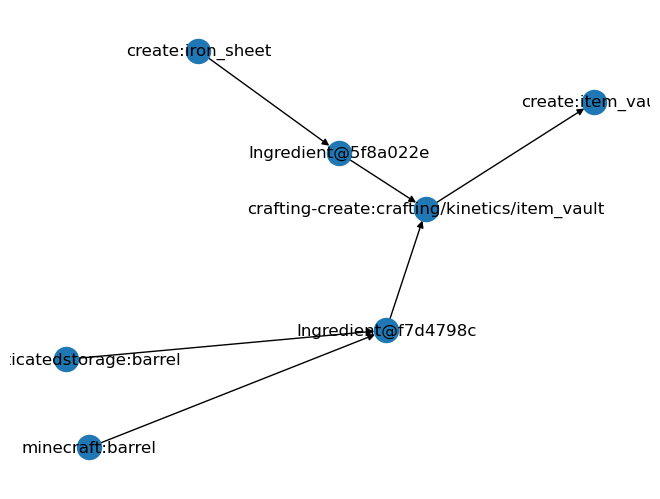

In [5]:
rev = nx.reverse(gc.G)
graph = {"create:item_vault"}
for i in range(3):
    graph.update(nx.descendants_at_distance(rev, "create:item_vault", i+1))

graph = gc.G.subgraph(graph)

nx.draw_spring(graph, with_labels=True)

for node, data in graph.nodes.data():
    print(node, data)


In [4]:
graph.nodes["minecraft:barrel"]["SCT"] = {40}
graph.nodes["minecraft:barrel"]["hasComputed"] = True
graph.nodes["sophisticatedstorage:barrel"]["SCT"] = {60,65}
graph.nodes["sophisticatedstorage:barrel"]["hasComputed"] = True
graph.nodes["create:iron_sheet"]["SCT"] = {20, 10}
graph.nodes["create:iron_sheet"]["hasComputed"] = True

import core

reload(core)

from core.solver.IngredientSolver import IngredientSolver
from core.solver.RecipeSolver import RecipeSolver
from core.solver.ItemSolver import ItemSolver

solver = IngredientSolver("Ingredient@cba37a15", graph)
solver.solve()
print(graph.nodes["Ingredient@cba37a15"]["SCT"])

solver = IngredientSolver("Ingredient@335902b7", graph)
solver.solve()
print(graph.nodes["Ingredient@335902b7"]["SCT"])

solver = RecipeSolver("crafting-create:crafting/kinetics/item_vault", graph)
solver.solve()
print(graph.edges["Ingredient@cba37a15", "crafting-create:crafting/kinetics/item_vault"])
print(graph.edges["Ingredient@335902b7", "crafting-create:crafting/kinetics/item_vault"])
print(graph.nodes["crafting-create:crafting/kinetics/item_vault"]["SCT"])

solver = ItemSolver("create:item_vault", graph)
solver.solve()
print(graph.edges["crafting-create:crafting/kinetics/item_vault","create:item_vault"])
print(graph.nodes["create:item_vault"]["SCT"])


INFO - IngredientSolver - solver - Solving Ingredient@cba37a15
INFO - IngredientSolver - selectionMethod - Candidates {40.0, 65.0, 60.0} have been reduced to 40.0
INFO - IngredientSolver - solver - Ingredient@cba37a15 has values {40.0}
INFO - IngredientSolver - solver - Solving Ingredient@335902b7
INFO - IngredientSolver - selectionMethod - Candidates {10.0, 20.0} have been reduced to 10.0
INFO - IngredientSolver - solver - Ingredient@335902b7 has values {10.0}
INFO - RecipeSolver - solver - Solving crafting-create:crafting/kinetics/item_vault
INFO - RecipeSolver - solver - crafting-create:crafting/kinetics/item_vault has values {60.0}
INFO - ItemSolver - solver - Solving create:item_vault
INFO - ItemSolver - solver - create:item_vault has values {60.0}


{40.0}
{10.0}
{'weight': 1}
{'weight': 2}
{60.0}
{'weight': 1}
{60.0}


In [5]:
for node,data in gc.G.nodes.data():
    if data["type"] == "cycle":
        print(node, len(data["subgraph"].nodes))

cycle-0 6
cycle-1 7
cycle-2 7
cycle-3 7
cycle-4 7
cycle-5 7
cycle-6 7
cycle-7 7
cycle-8 7
cycle-9 7
cycle-10 7
cycle-11 7
cycle-12 7
cycle-13 7
cycle-14 7
cycle-15 7
cycle-16 7
cycle-17 7
cycle-18 7
cycle-19 7
cycle-20 7
cycle-21 7
cycle-22 7
cycle-23 7
cycle-24 7
cycle-25 7
cycle-26 3
cycle-27 3
cycle-28 10
cycle-29 3
cycle-30 3
cycle-31 3
cycle-32 3
cycle-33 35
cycle-34 7
cycle-35 7
cycle-36 7
cycle-37 7
cycle-38 3
cycle-39 3
cycle-40 17
cycle-41 7
cycle-42 7
cycle-43 7
cycle-44 7
cycle-45 7
cycle-46 7
cycle-47 7
cycle-48 7
cycle-49 7
cycle-50 7
cycle-51 7
cycle-52 7
cycle-53 7
cycle-54 7
cycle-55 7
cycle-56 7
cycle-57 7
cycle-58 7
cycle-59 7
cycle-60 7
cycle-61 7
cycle-62 7
cycle-63 7
cycle-64 7
cycle-65 7
cycle-66 7
cycle-67 7
cycle-68 7
cycle-69 7
cycle-70 7
cycle-71 9
cycle-72 6
cycle-73 32
cycle-74 6
cycle-75 6
cycle-76 53
cycle-77 6
cycle-78 14
cycle-79 55
cycle-80 6
cycle-81 6
cycle-82 3
cycle-83 6
cycle-84 6
cycle-85 5
cycle-86 3
cycle-87 6
cycle-88 3
cycle-89 3
cycle-90 3
cy

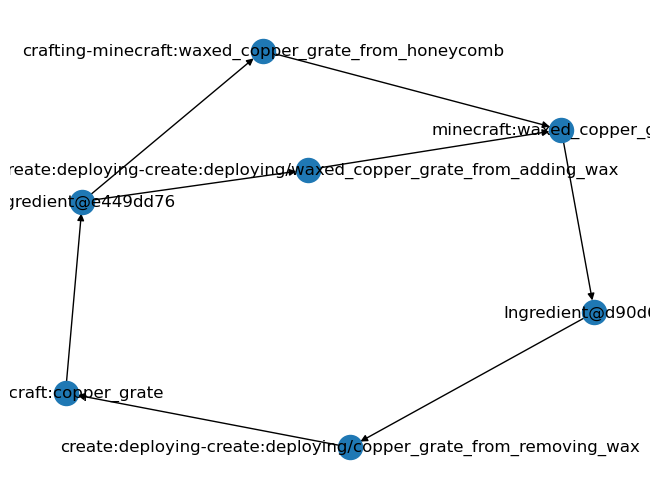

{'Ingredient@ed76c61b', 'stonecutting-minecraft:waxed_copper_grate_from_waxed_copper_block_stonecutting', 'Ingredient@ad16d5c4', 'crafting-minecraft:copper_grate', 'crafting-minecraft:waxed_copper_grate', 'Ingredient@1efd5258', 'create:deploying-create:deploying/copper_grate_from_deoxidising', 'stonecutting-minecraft:copper_grate_from_copper_block_stonecutting'}


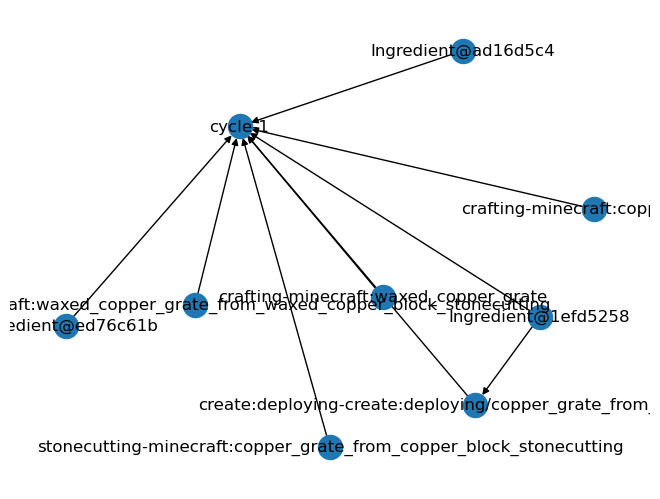

In [5]:
from matplotlib import pyplot as plt

nx.draw_spring(gc.G.nodes["cycle-1"]["subgraph"], with_labels=True)
plt.show()
graph = {"cycle-1"}
des = nx.descendants_at_distance(rev, "cycle-1", 1)
print(des)
graph.update(des)

graph = gc.G.subgraph(graph).copy()

nx.draw_spring(graph, with_labels=True)
plt.show()

In [7]:
for e in graph.edges.data():
    print(e)

('crafting-minecraft:waxed_copper_grate', 'cycle-1', {})
('Ingredient@1efd5258', 'create:deploying-create:deploying/copper_grate_from_deoxidising', {'weight': 1})
('Ingredient@1efd5258', 'cycle-1', {})
('stonecutting-minecraft:waxed_copper_grate_from_waxed_copper_block_stonecutting', 'cycle-1', {})
('Ingredient@ad16d5c4', 'cycle-1', {})
('crafting-minecraft:copper_grate', 'cycle-1', {})
('Ingredient@ed76c61b', 'cycle-1', {})
('stonecutting-minecraft:copper_grate_from_copper_block_stonecutting', 'cycle-1', {})
('create:deploying-create:deploying/copper_grate_from_deoxidising', 'cycle-1', {})


In [6]:
inputs = {
    'Ingredient@1efd5258' : 10,
    'stonecutting-minecraft:copper_grate_from_copper_block_stonecutting' : 15,
    'Ingredient@ed76c61b' : 7,
    'stonecutting-minecraft:waxed_copper_grate_from_waxed_copper_block_stonecutting': 20, 'create:deploying-create:deploying/copper_grate_from_deoxidising' : 12,
    'crafting-minecraft:copper_grate' : 6,
    'Ingredient@ad16d5c4' : 3,
    'crafting-minecraft:waxed_copper_grate' : 40
}

for key, val in inputs.items():
    graph.nodes[key]["SCT"] = {val}
    graph.nodes[key]["hasComputed"] = True

In [8]:
from core.solver.CycleSolver import CycleSolver

g = graph.copy()
solver = CycleSolver("cycle-1", g)
solver.solve()


INFO - CycleSolver - solver - Solving cycle-1
DEBUG - CycleSolver - solver - Init subnode crafting-minecraft:waxed_copper_grate_from_honeycomb with values {3.0}
DEBUG - CycleSolver - solver - Init subnode minecraft:waxed_copper_grate with values {10.0, 5.0}
DEBUG - CycleSolver - solver - Init subnode minecraft:copper_grate with values {1.5, 3.75, 12.0}
DEBUG - CycleSolver - solver - Init subnode create:deploying-create:deploying/waxed_copper_grate_from_adding_wax with values {7.0}
DEBUG - CycleSolver - solver - Init subnode create:deploying-create:deploying/copper_grate_from_removing_wax with values {10.0}
INFO - CycleSolver - solver - cycle-1 subnodes have been initialized
DEBUG - CycleSolver - solver - Starting cycle iteration 0
DEBUG - CycleSolver - solver - Subnode is Ingredient@d90d675f
INFO - CycleSolver - selectionMethod - Candidates {10.0, 5.0} have been reduced to 5.0
DEBUG - CycleSolver - solver - Subnode is crafting-minecraft:waxed_copper_grate_from_honeycomb
DEBUG - CycleSo

In [3]:
initset = set(nx.all_neighbors(gc.G, "cycle-48"))
for n in initset.copy():
    initset.update(nx.all_neighbors(gc.G, n))

initset.update(gc.G.predecessors("cycle-73"))
initset.update(gc.G.predecessors("cycle-176"))
initset.update(gc.G.predecessors("cycle-155"))

graph = gc.G.subgraph(initset).copy()
for n, data in graph.copy().nodes.data():
    if data["type"] != "item" and graph.in_degree(n) == 0:
        graph.remove_node(n)

#plotGraph(graph, "test", 1000)

In [4]:
%autoreload 2

prop = Propagation(graph.copy())
#prop.generateAtomicInputs()
#prop.saveAtomicInputs()
prop.loadAtomicInputs()
prop.setupForSolving()
#prop.solve()

INFO - Propagation - loadAtomicInputs - Found an existing input file
INFO - Propagation - setupForSolving - Starting values initialized
INFO - Propagation - setupForSolving - Starting computing nodes setup
INFO - Propagation - setupForSolving - [Delayed('lambda-3dee19da-f175-454a-b3ea-1ecd050d7720'), Delayed('lambda-fd844f44-058e-41ad-b654-84840cfc2e45'), Delayed('lambda-66ce1485-8f67-44f5-9213-77772192082d'), Delayed('lambda-6e635b68-aa8b-47b1-ba28-4718b3f8a9a1'), Delayed('lambda-6c31d3ca-ae6b-4a3b-a6f4-142a5df47ece'), Delayed('lambda-81fd760d-70ea-4299-bcba-6b532c2f3d13'), Delayed('lambda-ee6eff75-2981-4267-bff9-b3fba755cd24'), Delayed('lambda-da62c240-42bf-46c5-90c7-85f80145ac24'), Delayed('lambda-c587b4b5-cb31-484b-868a-8a92c13605b1'), Delayed('lambda-ca62b40f-0cb0-46e9-a043-7e3c5a2015e7'), Delayed('lambda-58875ea3-9188-4464-a6d0-a3c76aaa8372'), Delayed('lambda-b1b13b1d-54f0-41b0-be82-c2edb96b2d82'), Delayed('lambda-5b5a14ca-6936-4105-9bda-1f04a34317e8'), Delayed('lambda-f9bc89dd-4

In [17]:
prop.solve()

INFO - Propagation - solve - Starting node computing


In [13]:
outputs = pd.DataFrame(columns=["item","value"])
for node,data in prop.graph.nodes.data():
    if data["type"] == "item":
        outputs.loc[len(outputs)] = [node, data["SCT"]]
    if data['type'] == "cycle":
        for subnode, subdata in data["subgraph"].nodes.data():
            if subdata["type"] == "item":
                outputs.loc[len(outputs)] = [subnode, subdata["SCT"]]


In [12]:
pd.set_option('display.max_rows', 200)
display(outputs)
pd.set_option('display.max_rows', 30)

,item,value
0,create:oxidized_copper_tile_stairs,{390.0}
1,create:waxed_oxidized_copper_tile_stairs,"{570.0, 390.0}"
2,create:exposed_copper_tile_slab,"{5.0, 70.0}"
3,create:waxed_exposed_copper_tile_slab,"{65.0, 245.0}"
4,minecraft:waxed_oxidized_cut_copper,"{570.0, 390.0}"
5,minecraft:oxidized_cut_copper,{390.0}
6,create:weathered_copper_tile_slab,"{5.0, 70.0}"
7,create:waxed_weathered_copper_tile_slab,"{65.0, 245.0}"
8,minecraft:exposed_cut_copper_slab,"{5.0, 70.0}"
9,minecraft:waxed_exposed_cut_copper_slab,"{65.0, 245.0}"


In [24]:
for layer in nx.topological_generations(graph):
    print(layer)
    print([set(graph.predecessors(n)) for n in layer])
    print()

['minecraft:diamond_axe', 'minecraft:stone_axe', 'faz_roleplay_plus:fireman_axe', 'minecraft:netherite_axe', 'minecraft:wooden_axe', 'minecraft:honeycomb']
[set(), set(), set(), set(), set(), set()]

['Ingredient@92754b80', 'Ingredient@3e160d8e']
[{'faz_roleplay_plus:fireman_axe', 'minecraft:netherite_axe', 'minecraft:wooden_axe', 'minecraft:stone_axe', 'minecraft:diamond_axe'}, {'minecraft:honeycomb'}]

['crafting-mcwlights:iron_low_candle_holder', 'crafting-mcwlights:iron_chandelier', 'crafting-mcwlights:iron_double_candle_holder', 'crafting-supplementaries:fine_wood', 'crafting-mcwlights:iron_candle_holder', 'crafting-mcwlights:iron_triple_candle_holder', 'crafting-mcwlights:golden_triple_candle_holder', 'crafting-minecraft:candle', 'crafting-mcwlights:golden_low_candle_holder', 'crafting-mcwlights:golden_wall_candle_holder', 'crafting-mcwlights:golden_candle_holder', 'crafting-minecraft:honeycomb_block', 'crafting-mcwlights:golden_double_candle_holder', 'crafting-mcwlights:iron_wal

In [1]:
from core.GraphCreator import GraphCreator
from core.PlotGraph import plotGraph
from core.PropagationAlgorithm import Propagation

gc = GraphCreator("config/items.txt", "config/recipes.json", "config/equivalencyTags.json", "config/CustomRecipe.json")


INFO - GraphCreator - _generateGraph - Generating Graph
INFO - GraphCreator - _generateGraph - Added 6239 item nodes
INFO - GraphCreator - _generateGraph - Added 1979 ingredient nodes
INFO - GraphCreator - _generateGraph - Added 6567 recipe nodes
INFO - GraphCreator - __init__ - Full graph with following info : DiGraph with 14793 nodes and 21711 edges
INFO - GraphCreator - _makeLinks - Found 130 equivalency tags
INFO - GraphCreator - _makeLinks - Adding tag #comforts:hammock, replacing 16 nodes
INFO - GraphCreator - _makeLinks - Adding tag #comforts:sleeping_bag, replacing 16 nodes
INFO - GraphCreator - _makeLinks - Adding tag #create:postbox, replacing 16 nodes
INFO - GraphCreator - _makeLinks - Adding tag #create:seat, replacing 16 nodes
INFO - GraphCreator - _makeLinks - Adding tag #create:table_cloth, replacing 16 nodes
INFO - GraphCreator - _makeLinks - Adding tag #create:toolbox, replacing 16 nodes
INFO - GraphCreator - _makeLinks - Adding tag #create:valve_handle, replacing 17 n

In [2]:
prop = Propagation(gc.G, "config/bannedKeywords.json")

In [3]:
prop.generateAtomicInputs()
prop.crossmatchAtomicInputs("config/mainItemReference.csv")
prop.saveAtomicInputs()

INFO - Propagation - generateAtomicInputs - Getting atomic inputs
WARNING - Propagation - generateAtomicInputs - Cycle detected: cycle-149 with 63 nodes
WARNING - Propagation - generateAtomicInputs - Cycle detected: cycle-154 with 63 nodes
WARNING - Propagation - generateAtomicInputs - Cycle detected: cycle-155 with 63 nodes
WARNING - Propagation - generateAtomicInputs - Cycle detected: cycle-159 with 63 nodes
WARNING - Propagation - generateAtomicInputs - Cycle detected: cycle-160 with 63 nodes
WARNING - Propagation - generateAtomicInputs - Cycle detected: cycle-161 with 6 nodes
WARNING - Propagation - generateAtomicInputs - Cycle detected: cycle-166 with 63 nodes
WARNING - Propagation - generateAtomicInputs - Cycle detected: cycle-170 with 6 nodes
WARNING - Propagation - generateAtomicInputs - Cycle detected: cycle-172 with 63 nodes
WARNING - Propagation - generateAtomicInputs - Cycle detected: cycle-175 with 6 nodes
WARNING - Propagation - generateAtomicInputs - Cycle detected: cycl

In [4]:
prop.setupForSolving()

TypeError: cannot convert dictionary update sequence element #0 to a sequence